# UT4 - Práctica 9: Detección de Rostros (Viola-Jones) y Filtros AR
**Objetivo:** Utilizar clasificadores en cascada pre-entrenados (Haar Cascades) para detectar rostros y rasgos faciales, y aplicar máscaras para crear un filtro de Realidad Aumentada estilo Snapchat.

---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# --- DESCARGA DE MATERIALES ---
# URLs de los recursos
url_foto = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
url_gafas = "https://upload.wikimedia.org/wikipedia/commons/c/cf/Thug_Life_Glasses.png"

url_xml_face = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
url_xml_eye = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml"

# Función para descargar
def descargar_archivo(url, nombre_archivo):
    print(f"Descargando {nombre_archivo}...")
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})
    with open(nombre_archivo, "wb") as f:
        f.write(urllib.request.urlopen(req).read())

# Descargamos todo
descargar_archivo(url_foto, "cara_prueba.jpg")
descargar_archivo(url_gafas, "gafas.png")
descargar_archivo(url_xml_face, "cascade_cara.xml")
descargar_archivo(url_xml_eye, "cascade_ojos.xml")

print("Entorno preparado y materiales descargados correctamente.")

Descargando cara_prueba.jpg...
Descargando gafas.png...
Descargando cascade_cara.xml...
Descargando cascade_ojos.xml...
Entorno preparado y materiales descargados correctamente.


### Paso 1: Preparar la función de mostrar imágenes en el Notebook
Queremos una función que:
- Si la imagen está en BGR se pase a RGB y se muestre.
- Si está en escala de grises se muestre directamente mapeando de negro a blanco.

In [2]:
# Define la función 'mostrar(img, titulo="Imagen")'
# 1. Crea una figura con matplotlib (ej. figsize=(8,6))
# 2. Comprueba si la imagen tiene 3 canales (color BGR). Si es así, conviértela a RGB con cv2.cvtColor
# 3. Muestra la imagen con plt.imshow (usa cmap='gray' si no tiene 3 canales)
# 4. Pon el título, quita los ejes (plt.axis('off')) y muestra la figura (plt.show())

def mostrar(img, titulo="Imagen"):
    plt.figure(figsize=(8,6))
    alto, ancho, canales = img.shape
    if canales == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
    else:
        plt.imshow(img, cmap="gray")
    plt.title(titulo)
    plt.axis('off')
    plt.show()


### Paso 2: Detección Básica de la Cara
El algoritmo de Viola-Jones necesita que la imagen esté en **escala de grises** porque analiza el contraste de la luz, no los colores.
Usaremos la función `detectMultiScale`, que busca el patrón a diferentes tamaños (por si la persona está cerca o lejos de la cámara).

Número de caras encontradas: 1


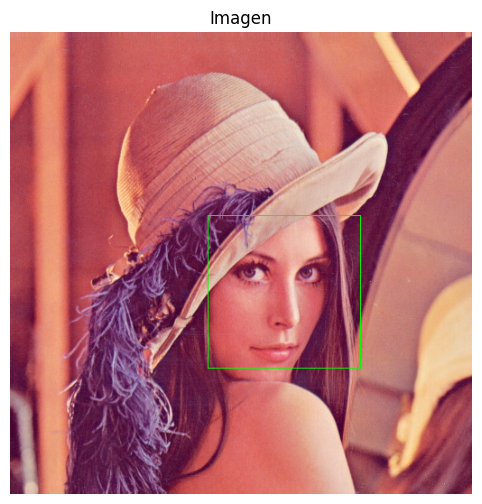

In [3]:
# 1. Carga el modelo pre-entrenado de caras usando cv2.CascadeClassifier ('cascade_cara.xml')

# 2. Lee la imagen 'cara_prueba.jpg' y conviértela a escala de grises

# 3. Detecta las caras usando el método detectMultiScale sobre la imagen en grises.
# Pista: usa scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)

# 4. Imprime por pantalla cuántas caras se han encontrado

# 5. Haz una copia de la imagen original a color

# 6. Recorre las caras detectadas (for (x, y, w, h) in caras:)
#    y dibuja un rectángulo verde alrededor de cada una usando cv2.rectangle

# 7. Muestra la imagen resultante usando la función 'mostrar'

modelo_caras = cv2.CascadeClassifier('cascade_cara.xml')
img_cara = cv2.imread('cara_prueba.jpg')
img_cara_gray = cv2.cvtColor(img_cara, cv2.COLOR_BGR2GRAY)
deteccion_caras = modelo_caras.detectMultiScale(img_cara_gray, 1.1, 5, minSize= (30, 30))
print('Número de caras encontradas:', len(deteccion_caras))
img_cara_copy = img_cara.copy()
for (x, y, w, h) in deteccion_caras:
    cv2.rectangle(img_cara_copy, (x, y), (x + w, y + h), (0, 255, 0))
mostrar(img_cara_copy)

### Paso 3: La Región de Interés (ROI) y los Ojos
Sabemos que los ojos siempre están *dentro* de la cara. Para que el ordenador vaya más rápido y no encuentre "falsos ojos" en los pliegues de la ropa o en el fondo, vamos a recortar la cara detectada (ROI) y buscaremos los ojos **solo ahí dentro**.

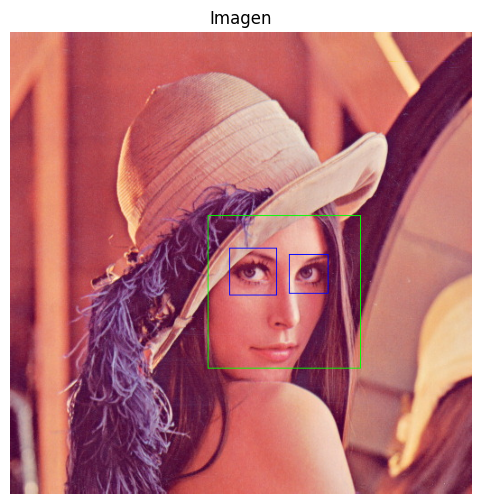

In [4]:
# 1. Carga el modelo de ojos usando cv2.CascadeClassifier ('cascade_ojos.xml')

# 2. Haz una copia de la imagen original para dibujar sobre ella

# 3. Haz un bucle sobre las caras detectadas (como en el paso anterior)
#    a) Dibuja el rectángulo de la cara
#    b) Extrae la Región de Interés (ROI) de la cara tanto en la imagen en grises como en la de color
#       Pista: roi_gris = gris[y:y+h, x:x+w]
#    c) Detecta los ojos DENTRO de la roi_gris usando detectMultiScale (ej: scaleFactor=1.1, minNeighbors=10)
#    d) Haz un bucle sobre los ojos detectados (ox, oy, ow, oh)
#       y dibuja un rectángulo azul alrededor de cada ojo sobre la roi_color

# 4. Muestra la imagen con las caras y los ojos resaltados

modelo_ojos = cv2.CascadeClassifier('cascade_ojos.xml')
deteccion_caras = modelo_caras.detectMultiScale(img_cara_gray, 1.1, 5, minSize= (30, 30))
img_cara_copy = img_cara.copy()
for (x, y, w, h) in deteccion_caras:
    cv2.rectangle(img_cara_copy, (x, y), (x + w, y + h), (0, 255, 0))
    roi_gris = img_cara_gray[y:y+h, x:x+w]
    roi_color = img_cara_copy[y:y+h, x:x+w]
    deteccion_ojos = modelo_ojos.detectMultiScale(roi_gris, 1.1, 10)
    for (ox, oy, ow, oh) in deteccion_ojos:
        cv2.rectangle(roi_color, (ox, oy), (ox + ow, oy + oh), (255, 0, 0))
mostrar(img_cara_copy)


### RETO FINAL: Thug Life Lena
¡Hora de la magia! Tienes una imagen llamada `gafas.png` que tiene fondo transparente (4 canales de color: BGRA, donde la 'A' es el canal Alfa de transparencia).

**Tu misión:**
1. Detectar la cara y los ojos.
2. Calcular la anchura que deben tener las gafas (pista: usa el ancho `w` de la cara).
3. Redimensionar la imagen de las gafas a ese tamaño.
4. Usar las máscaras del canal Alfa para superponer las gafas sobre los ojos sin tapar el fondo con un recuadro negro.

In [ ]:
# 1. Lee la imagen base ('cara_prueba.jpg')
# 2. Lee la imagen de las gafas ('gafas.png') CON el canal alfa. 
#    Pista clave: usa el flag cv2.IMREAD_UNCHANGED

# 3. Pasa la imagen base a grises y detecta las caras

# 4. Haz un bucle para cada cara detectada:
#    a) Calcula el ancho que deben tener las gafas (ej: el 90% del ancho de la cara, 'w')
#    b) Calcula la proporción para redimensionar las gafas sin deformarlas
#    c) Redimensiona la imagen de las gafas con cv2.resize
#    d) Extrae los 3 primeros canales de las gafas (los colores BGR) y el 4º canal (la máscara Alpha)
#    e) Invierte la máscara Alpha con cv2.bitwise_not para saber cuál es el fondo de la gafa
#    f) Calcula la posición (y_offset, x_offset) donde irán las gafas (ej: y + un tercio de 'h')
#    g) Extrae la ROI del fondo de la imagen original donde se colocarán las gafas
#    h) Usa cv2.bitwise_and para "apagar" (poner a negro) los píxeles del fondo usando la máscara invertida
#    i) Usa cv2.bitwise_and para extraer los colores de las gafas usando la máscara normal
#    j) Suma el fondo preparado y las gafas limpias usando cv2.add
#    k) Sustituye la ROI en la imagen original con este nuevo resultado combinado

# 5. Muestra el resultado final

img_cara = cv2.imread('cara_prueba.jpg')
img_gafas = cv2.imread('gafas.png', cv2.IMREAD_UNCHANGED)
alto_gafas, ancho_gafas, canales_gafas = img_gafas.shape
B, G, R, A = cv2.split(img_gafas)
cv2.bitwise_not(img_gafas)

modelo_caras = cv2.CascadeClassifier('cascade_cara.xml')
modelo_ojos = cv2.CascadeClassifier('cascade_ojos.xml')

img_cara_gray = cv2.cvtColor(img_cara, cv2.COLOR_BGR2GRAY)
deteccion_caras = modelo_caras.detectMultiScale(img_cara_gray, 1.1, 5, minSize= (30, 30))

for (x, y, w, h) in deteccion_caras:
    w_gafas = 0.9 * w
    proporcion = w_gafas / ancho_gafas
    nuevo_alto_gafas = alto_gafas * proporcion
    img_gafas = cv2.resize(img_gafas, (w_gafas, nuevo_alto_gafas))
    y_offset = y + (0.33 * h)
    x_offset = w
    #TODO g)
    

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'resize'
> Overload resolution failed:
>  - Can't parse 'dsize'. Sequence item with index 0 has a wrong type
>  - Can't parse 'dsize'. Sequence item with index 0 has a wrong type


### Ejercicio Webcam